In [16]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\ANIKET\Downloads\forestfires.csv")

In [3]:
df.head()


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [4]:
print(df.columns)


Index(['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH',
       'wind', 'rain', 'area'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [6]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [7]:
mapped = df['month'].apply(lambda x: (x, 1))
mapped.head()

0    (mar, 1)
1    (oct, 1)
2    (oct, 1)
3    (mar, 1)
4    (mar, 1)
Name: month, dtype: object

In [8]:
from collections import defaultdict

reduced = defaultdict(int)

for key, value in mapped:
    reduced[key] += value

# Convert to DataFrame
result1 = pd.DataFrame(list(reduced.items()), columns=['Month', 'Fire_Count'])
result1.sort_values(by='Fire_Count', ascending=False)

,Month,Fire_Count
2,aug,184
3,sep,172
0,mar,54
6,jul,32
7,feb,20
5,jun,17
1,oct,15
4,apr,9
9,dec,9
8,jan,2


In [9]:
mapped_temp = df.apply(lambda row: (row['month'], row['temp']), axis=1)

In [10]:
temp_data = defaultdict(list)

for key, value in mapped_temp:
    temp_data[key].append(value)

# Calculate average
avg_temp = {k: sum(v)/len(v) for k, v in temp_data.items()}

result2 = pd.DataFrame(list(avg_temp.items()), columns=['Month', 'Avg_Temp'])
result2.sort_values(by='Avg_Temp', ascending=False)

,Month,Avg_Temp
6,jul,22.109375
2,aug,21.631522
5,jun,20.494118
3,sep,19.612209
1,oct,17.093333
10,may,14.650000
0,mar,13.083333
4,apr,12.044444
11,nov,11.800000
7,feb,9.635000


In [11]:
mapped_area = df.apply(lambda row: (row['day'], row['area']), axis=1)

In [12]:
area_data = defaultdict(float)

for key, value in mapped_area:
    area_data[key] += value

result3 = pd.DataFrame(list(area_data.items()), columns=['Day', 'Total_Area'])
result3.sort_values(by='Total_Area', ascending=False)

,Day,Total_Area
2,sat,2144.86
6,thu,997.10
3,sun,959.93
1,tue,807.79
4,mon,706.53
5,wed,578.60
0,fri,447.24


In [13]:
print("Fire Count per Month:")
print(result1)

print("\nAverage Temperature per Month:")
print(result2)

print("\nTotal Burned Area per Day:")
print(result3)

Fire Count per Month:
   Month  Fire_Count
0    mar          54
1    oct          15
2    aug         184
3    sep         172
4    apr           9
5    jun          17
6    jul          32
7    feb          20
8    jan           2
9    dec           9
10   may           2
11   nov           1

Average Temperature per Month:
   Month   Avg_Temp
0    mar  13.083333
1    oct  17.093333
2    aug  21.631522
3    sep  19.612209
4    apr  12.044444
5    jun  20.494118
6    jul  22.109375
7    feb   9.635000
8    jan   5.250000
9    dec   4.522222
10   may  14.650000
11   nov  11.800000

Total Burned Area per Day:
   Day  Total_Area
0  fri      447.24
1  tue      807.79
2  sat     2144.86
3  sun      959.93
4  mon      706.53
5  wed      578.60
6  thu      997.10


In [14]:


df.groupby('month')['temp'].mean()
df.groupby('month').size()
df.groupby('day')['area'].sum()

day
fri     447.24
mon     706.53
sat    2144.86
sun     959.93
thu     997.10
tue     807.79
wed     578.60
Name: area, dtype: float64

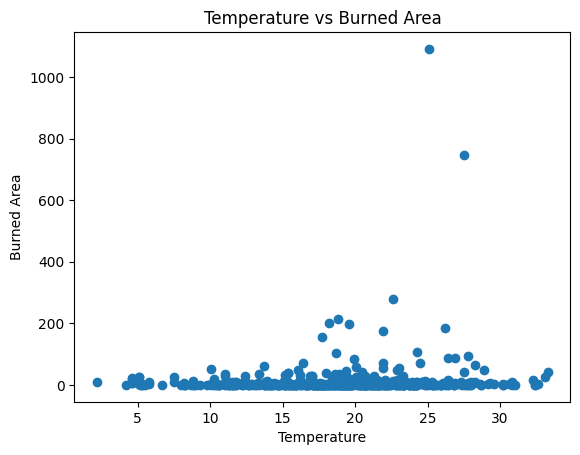

In [17]:
plt.scatter(df['temp'], df['area'])

plt.xlabel("Temperature")
plt.ylabel("Burned Area")
plt.title("Temperature vs Burned Area")

plt.show()

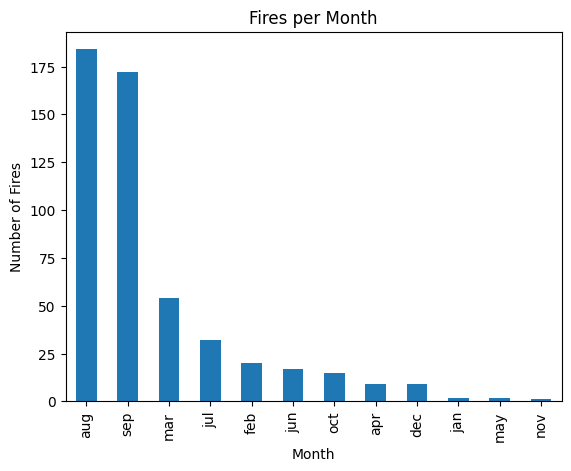

In [18]:
month_counts = df['month'].value_counts()

plt.figure()

month_counts.plot(kind='bar')

plt.xlabel("Month")
plt.ylabel("Number of Fires")
plt.title("Fires per Month")

plt.show()

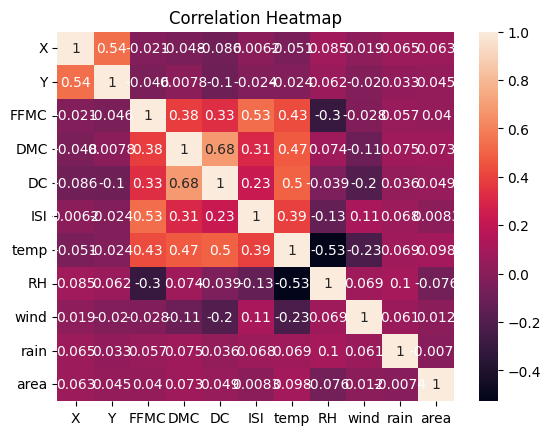

In [19]:
plt.figure()

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()